In [21]:
import matplotlib.pyplot as plt
from sc_flow.backends.torchax.methods._methods import FlowMatching
from sc_flow.backends.torchax.nn._vf import MLPUnconditionalVF
from sc_flow.backends.torchax.probability_paths import LinearDiracProbabilityPath
from sc_flow.trainer._trainer import FlowTrainer
import jax
import numpy as np

import torchax
import torch

torchax.enable_globally()

In [22]:
vf = MLPUnconditionalVF(
    state_dim=2,
    encode_state=True,
    encode_time=True,
    time_features_id="torch-cfm",
    state_encoder_mlp_kwargs={"hidden_dims": (32,)},
    time_encoder_mlp_kwargs={"hidden_dims": (16,)},
    vf_decoder_mlp_kwargs={"hidden_dims": (64, 64)},
)

In [23]:
vf

MLPUnconditionalVF(
  (_vf): ModuleDict(
    (time_features): FunctionalModule(
      (_identity): Identity()
    )
    (time_encoder): MLP(
      (_mlp): Sequential(
        (layer_0): Sequential(
          (linear): Linear(in_features=256, out_features=16, bias=True)
          (activation): ReLU()
        )
        (layer_1): Sequential(
          (linear): Linear(in_features=16, out_features=16, bias=True)
          (activation): Identity()
        )
      )
    )
    (state_encoder): MLP(
      (_mlp): Sequential(
        (layer_0): Sequential(
          (linear): Linear(in_features=2, out_features=32, bias=True)
          (activation): ReLU()
        )
        (layer_1): Sequential(
          (linear): Linear(in_features=32, out_features=32, bias=True)
          (activation): Identity()
        )
      )
    )
    (conditioning_layer): ConcatConditioning(
      (_identity): Identity()
    )
    (vf_decoder): MLP(
      (_mlp): Sequential(
        (layer_0): Sequential(
          (

In [ ]:
# 2. Define your time sampler function
def time_sampler(key, shape):
    """Sample random time points uniformly between 0 and 1."""
    return jax.random.uniform(key, shape=shape)

In [25]:
method = FlowMatching(
    vf=vf,
    probability_path=LinearDiracProbabilityPath(sigma=0.0),
    time_sampler=time_sampler,
)

In [26]:
trainer = FlowTrainer(method=method, require_prng=False)

In [27]:
from sc_flow._runtime import BACKEND

In [28]:
BACKEND

'torch'

In [29]:
from abc import ABC, abstractmethod
from typing import Any

import scanpy as sc


class BaseDummyDataset(ABC):
    """
    Abstract base class for all dummy dataset generators.

    Attributes
    ----------
    random_state : int
        Random seed for reproducibility across all dataset types

    dataset_name : str
        Identifier for the dataset type (e.g., 'blobs', 'moons')
    """

    def __init__(self, random_state: int, n_samples: int, n_features: int, **kwargs):
        """
        Initialize the base dataset generator.

        Parameters
        ----------
        random_state : int, optional (default=42)
            Seed for random number generation to ensure reproducibility
        """
        self.dataset_name = self._get_dataset_name()
        self.random_state = random_state
        self._validate_parameters(random_state, n_samples, n_features, **kwargs)
        self.adata = self._generate(random_state, n_samples, n_features, **kwargs)

    def _create_anndata(
        self, X: np.ndarray, y: np.ndarray | None = None, additional_obs: dict[str, np.ndarray] | None = None
    ) -> sc.AnnData:
        """
        Convert raw numpy arrays into AnnData format with standardized structure.

        Parameters
        ----------
        X : np.ndarray, shape (n_observations, n_features)
            Data matrix where each row is an observation (e.g., a cell)
            and each column is a feature (e.g., a gene or coordinate)

        y : np.ndarray, optional, shape (n_observations,)
            Cluster labels or class assignments for each observation

        additional_obs : dict, optional
            Additional observation-level annotations to store in .obs

        Returns
        -------
        adata : sc.AnnData
            Annotated data object with standardized structure
        """
        # Step 1: Create the core AnnData structure
        adata = sc.AnnData(X=X)

        # Step 2: Create standardized observation names
        n_obs = X.shape[0]
        adata.obs_names = [f"cell_{i}" for i in range(n_obs)]

        # Step 3: Create standardized variable (feature) names
        n_vars = X.shape[1]
        adata.var_names = [f"feature_{i}" for i in range(n_vars)]

        # Step 4: Add cluster labels if provided
        # Labels are stored as strings for categorical data
        if y is not None:
            adata.obs["labels"] = y.astype(str)
            adata.obs["labels"] = adata.obs["labels"].astype("category")

        # Step 5: Add any additional observation-level data
        if additional_obs is not None:
            for key, values in additional_obs.items():
                adata.obs[key] = values

        # Step 6: Store metadata about the dataset
        adata.uns["dataset_info"] = self._create_metadata(X)

        return adata

    def _create_metadata(self, X: np.ndarray) -> dict[str, Any]:
        """
        Create standardized metadata dictionary for the dataset.

        Parameters
        ----------
        X : np.ndarray
            The data matrix to extract shape information from

        Returns
        -------
        metadata : dict
            Dictionary containing dataset information
        """
        return {
            "name": self.dataset_name,
            "n_observations": X.shape[0],
            "n_features": X.shape[1],
            "random_state": self.random_state,
            "generator": self.__class__.__name__,
        }

    def _validate_parameters(self, random_state, n_samples: int, n_features: int, **kwargs) -> None:
        """
        Validate common parameters to prevent errors.

        Parameters
        ----------
        n_samples : int
            Number of observations to generate

        n_features : int
            Number of features (dimensions) for each observation

        Raises
        ------
        ValueError : If parameters are invalid
        """
        if not isinstance(n_samples, int):
            raise TypeError(f"n_samples must be an integer, got {type(n_samples)}")

        if not isinstance(n_features, int):
            raise TypeError(f"n_features must be an integer, got {type(n_features)}")

        if not isinstance(random_state, int):
            raise TypeError(f"random_state must be an integer, got {type(random_state)}")

        if n_samples <= 0:
            raise ValueError(f"n_samples must be positive, got {n_samples}")

        if n_features <= 0:
            raise ValueError(f"n_features must be positive, got {n_features}")

        self._validate_additional_parameters(**kwargs)

    @abstractmethod
    def _validate_additional_parameters(self, **kwargs) -> None:
        """Validate dataset-specific parameters."""
        raise NotImplementedError

    @abstractmethod
    def _get_dataset_name(self) -> str:
        """
        Return the name identifier for this dataset type.

        This is an abstract method - each child class must implement it.
        Example: BlobsDataset would return "blobs"

        Returns
        -------
        str : Name of the dataset
        """
        raise NotImplementedError

    @abstractmethod
    def _generate(self, **kwargs) -> sc.AnnData:
        """
        Generate the dataset with specific parameters.

        This is an abstract method - each child class must implement its own
        generation logic using sklearn or custom algorithms.

        Parameters
        ----------
        **kwargs : dict
            Dataset-specific parameters (e.g., n_samples, noise level)

        Returns
        -------
        adata : sc.AnnData
            Generated dataset wrapped in AnnData format
        """
        raise NotImplementedError

In [30]:
import scanpy as sc
from sklearn import datasets


class MoonsDataset(BaseDummyDataset):
    """
    Generate two interleaving half-circles (moons).

    Parameters
    ----------
    random_state : int, optional (default=42)
        Seed for random number generation to ensure reproducibility

    n_samples : int, optional (default=1000)
        Total number of samples to generate

    noise : float, optional (default=0.0)
        Standard deviation of Gaussian noise added to the data

    shuffle : bool, optional (default=True)
        Whether to shuffle the samples after generation
    """

    def __init__(self, random_state: int = 42, n_samples: int = 1000, noise: float = 0.0, shuffle: bool = True):
        """Initialization"""
        super().__init__(random_state, n_samples, n_features=2, noise=noise, shuffle=shuffle)

    def _get_dataset_name(self) -> str:
        """Return identifier for this dataset type."""
        return "moons"

    def _validate_additional_parameters(self, **kwargs):
        """Validate dataset-specific parameters."""
        noise = kwargs["noise"]
        shuffle = kwargs["shuffle"]

        if not isinstance(noise, int | float):
            raise TypeError(f"noise must be a number, got {type(noise)}")

        if noise < 0:
            raise ValueError(f"noise must be non-negative, got {noise}")

        if not isinstance(shuffle, bool):
            raise TypeError(f"shuffle must be a boolean, got {type(shuffle)}")

    def _generate(self, random_state, n_samples, n_features, noise, shuffle) -> sc.AnnData:
        """
        Generate interleaving half-circles (moons) dataset.

        Returns
        -------
        adata : sc.AnnData
            Dataset with two interleaving half-circles labeled as class 0 and 1
        """
        # Step 1: Generate moons using sklearn
        X, y = datasets.make_moons(n_samples=n_samples, noise=noise, random_state=random_state, shuffle=shuffle)

        # Step 2: Wrap in AnnData format
        adata = self._create_anndata(X, y)

        # Step 3: Add moons-specific metadata
        adata.uns["dataset_info"]["noise"] = noise
        adata.uns["dataset_info"]["shuffle"] = shuffle

        return adata

In [31]:
adata = MoonsDataset()._generate(n_samples=100_000, random_state=42, n_features=2, noise=0.1, shuffle=False)

In [ ]:
class DummyTrainLoader:
    """Dummy training data loader that generates random batches of source and target cells."""

    def __init__(self, adata, batch_size):
        self.adata = adata
        self.batch_size = batch_size

    def sample(self, _):
        """Generate a random batch of source and target cells for training."""
        return {
            "src_cell": torch.randn((self.batch_size, self.adata.X.shape[1])),
            "tgt_cell": torch.from_numpy(
                self.adata.X[np.random.choice(np.arange(1, self.adata.shape[0]), size=self.batch_size), :]
            ).to(dtype=torch.float32),
        }

In [33]:
train_loader = DummyTrainLoader(adata=adata, batch_size=512)

In [34]:
prng = jax.random.PRNGKey(42)

In [35]:
trainer.fit(train_dataloader=train_loader, num_iterations=500_000, valid_freq=100000, prng=prng)

100%|██████████| 500000/500000 [15:00<00:00, 555.11it/s]


(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

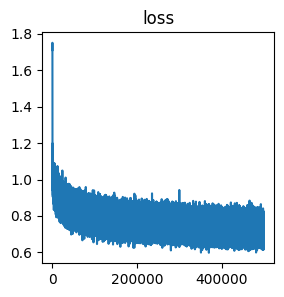

In [36]:
trainer.plot_training_logs()

In [37]:
data = train_loader.sample(None)

In [38]:
preds = trainer._method.predict(data["src_cell"])

(-3.0, 3.0)

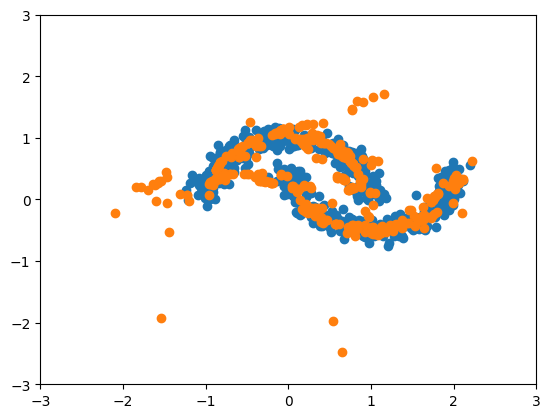

In [42]:
plt.scatter(data["tgt_cell"][:, 0], data["tgt_cell"][:, 1])
plt.scatter(preds[:, 0].detach().numpy(), preds[:, 1].detach().numpy())
plt.xlim([-3, 3])
plt.ylim([-3, 3])